# 01 — Data Cleaning

**Objective:** Validate and clean the raw Cookie Cats A/B test dataset before analysis.

**Steps:**
1. Load raw data and inspect structure
2. Check for missing values
3. Check for duplicate user IDs
4. Validate experiment group labels
5. Inspect and handle engagement outliers
6. Validate retention columns
7. Check sample balance between groups
8. Save cleaned data

**Input:** `../data/raw/cookie_cats.csv`  
**Output:** `../data/processed/cookie_cats_cleaned.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)

print('Libraries loaded ✓')

Libraries loaded ✓


---
## 1. Load Raw Data

In [2]:
df = pd.read_csv('../data/raw/cookie_cats.csv')

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: 90,189 rows × 5 columns
Columns: ['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [4]:
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


---
## 2. Check Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})

print('=== Missing Values ===')
print(missing_summary)

if missing.sum() == 0:
    print('\n✓ No missing values found.')
else:
    print(f'\n⚠ Total missing cells: {missing.sum()}')

=== Missing Values ===
                missing_count  missing_pct
userid                      0          0.0
version                     0          0.0
sum_gamerounds              0          0.0
retention_1                 0          0.0
retention_7                 0          0.0

✓ No missing values found.


---
## 3. Check Duplicate User IDs

In [6]:
total_users = len(df)
unique_users = df['userid'].nunique()
duplicate_count = total_users - unique_users

print(f'Total rows:    {total_users:,}')
print(f'Unique users:  {unique_users:,}')
print(f'Duplicates:    {duplicate_count:,}')

if duplicate_count == 0:
    print('\n✓ No duplicate user IDs — each user appears exactly once.')
else:
    print('\n⚠ Duplicates found — investigating...')
    print(df[df.duplicated(subset='userid', keep=False)].sort_values('userid').head(10))

Total rows:    90,189
Unique users:  90,189
Duplicates:    0

✓ No duplicate user IDs — each user appears exactly once.


---
## 4. Validate Experiment Group Labels

In [7]:
valid_versions = {'gate_30', 'gate_40'}
actual_versions = set(df['version'].unique())

print(f'Expected groups: {valid_versions}')
print(f'Actual groups:   {actual_versions}')

invalid_rows = df[~df['version'].isin(valid_versions)]
print(f'Invalid labels:  {len(invalid_rows)} rows')

if actual_versions == valid_versions:
    print('\n✓ Version labels are valid.')
else:
    print(f'\n⚠ Unexpected labels found: {actual_versions - valid_versions}')

Expected groups: {'gate_40', 'gate_30'}
Actual groups:   {'gate_40', 'gate_30'}
Invalid labels:  0 rows

✓ Version labels are valid.


In [8]:
# Group size breakdown
group_counts = df['version'].value_counts().reset_index()
group_counts.columns = ['version', 'count']
group_counts['pct'] = (group_counts['count'] / len(df) * 100).round(1)
print(group_counts)

   version  count   pct
0  gate_40  45489  50.4
1  gate_30  44700  49.6


---
## 5. Inspect Engagement Outliers (`sum_gamerounds`)

In [9]:
# Percentile breakdown
pcts = [0, 25, 50, 75, 90, 95, 99, 99.9, 100]
percentiles = df['sum_gamerounds'].quantile([p/100 for p in pcts])

print('=== sum_gamerounds Percentiles ===')
for p, val in zip(pcts, percentiles):
    print(f'  p{p:>5.1f}: {val:>8.0f}')

=== sum_gamerounds Percentiles ===
  p  0.0:        0
  p 25.0:        5
  p 50.0:       16
  p 75.0:       51
  p 90.0:      134
  p 95.0:      221
  p 99.0:      493
  p 99.9:     1074
  p100.0:    49854


In [10]:
# Identify extreme outliers (> 99th percentile)
p99 = df['sum_gamerounds'].quantile(0.99)
outlier_mask = df['sum_gamerounds'] > p99
outlier_count = outlier_mask.sum()
outlier_pct = outlier_count / len(df) * 100

print(f'99th percentile threshold: {p99:.0f} rounds')
print(f'Users above p99:           {outlier_count:,} ({outlier_pct:.2f}%)')
print(f'Max game rounds:           {df["sum_gamerounds"].max():,}')

# Zero-round users (installed but never played)
zero_rounds = (df['sum_gamerounds'] == 0).sum()
print(f'\nUsers with 0 rounds (never played): {zero_rounds:,} ({zero_rounds/len(df)*100:.1f}%)')

99th percentile threshold: 493 rounds
Users above p99:           898 (1.00%)
Max game rounds:           49,854

Users with 0 rounds (never played): 3,994 (4.4%)


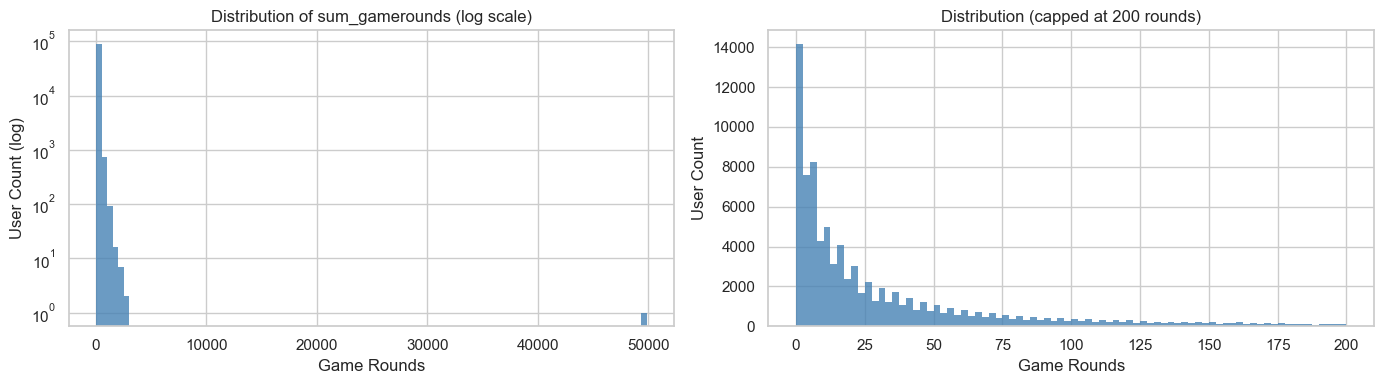

Figure saved ✓


In [11]:
# Visualise distribution — cap at 200 rounds for readability
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full distribution (log scale)
axes[0].hist(df['sum_gamerounds'], bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_title('Distribution of sum_gamerounds (log scale)')
axes[0].set_xlabel('Game Rounds')
axes[0].set_ylabel('User Count (log)')

# Right: capped at 200 for bulk of users
df_capped = df[df['sum_gamerounds'] <= 200]
axes[1].hist(df_capped['sum_gamerounds'], bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].set_title('Distribution (capped at 200 rounds)')
axes[1].set_xlabel('Game Rounds')
axes[1].set_ylabel('User Count')

plt.tight_layout()
plt.savefig('../outputs/figures/01_gamerounds_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved ✓')

**Observation:** `sum_gamerounds` is heavily right-skewed. A small number of power users play hundreds or thousands of rounds. 

**Decision:** We keep all users in the cleaned dataset (no rows dropped) because extreme outliers are real user behaviour. For statistical tests that are sensitive to outliers (e.g. mean comparison), we will use non-parametric methods (Mann-Whitney U) in the engagement analysis notebook.

---
## 6. Validate Retention Columns

In [12]:
for col in ['retention_1', 'retention_7']:
    unique_vals = df[col].unique()
    dtype = df[col].dtype
    true_count = df[col].sum()
    true_pct = true_count / len(df) * 100
    print(f'{col}')
    print(f'  dtype:         {dtype}')
    print(f'  unique values: {unique_vals}')
    print(f'  True (retained): {true_count:,} ({true_pct:.1f}%)')
    print(f'  False:           {len(df) - true_count:,} ({100 - true_pct:.1f}%)')
    print()

retention_1
  dtype:         bool
  unique values: [False  True]
  True (retained): 40,153 (44.5%)
  False:           50,036 (55.5%)

retention_7
  dtype:         bool
  unique values: [False  True]
  True (retained): 16,781 (18.6%)
  False:           73,408 (81.4%)



---
## 7. Sample Balance Check

In [13]:
ctrl = df[df['version'] == 'gate_30']
trt  = df[df['version'] == 'gate_40']

print('=== Sample Size Balance ===')
print(f'Control (gate_30):   {len(ctrl):,} users ({len(ctrl)/len(df)*100:.1f}%)')
print(f'Treatment (gate_40): {len(trt):,} users ({len(trt)/len(df)*100:.1f}%)')
print(f'Ratio (ctrl/trt):    {len(ctrl)/len(trt):.3f}')
print()

print('=== Engagement Summary by Group ===')
summary = df.groupby('version')['sum_gamerounds'].agg(
    mean='mean', median='median', std='std',
    p90=lambda x: x.quantile(0.9)
).round(2)
print(summary)

=== Sample Size Balance ===
Control (gate_30):   44,700 users (49.6%)
Treatment (gate_40): 45,489 users (50.4%)
Ratio (ctrl/trt):    0.983

=== Engagement Summary by Group ===
          mean  median     std    p90
version                              
gate_30  52.46    17.0  256.72  135.0
gate_40  51.30    16.0  103.29  134.0


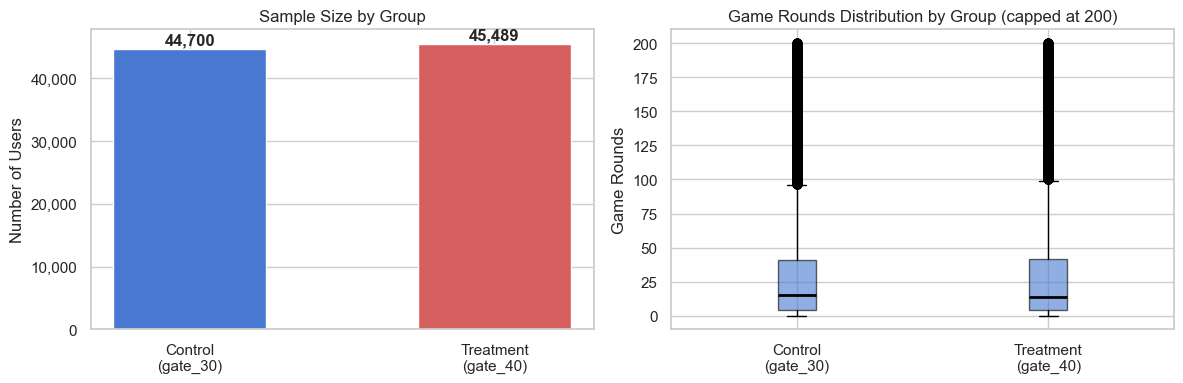

Figure saved ✓


In [14]:
# Visualise sample balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart: sample sizes
bars = axes[0].bar(
    ['Control\n(gate_30)', 'Treatment\n(gate_40)'],
    [len(ctrl), len(trt)],
    color=['#4878CF', '#D65F5F'],
    width=0.5
)
for bar, n in zip(bars, [len(ctrl), len(trt)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{n:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Sample Size by Group')
axes[0].set_ylabel('Number of Users')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Box plot: game rounds distribution (capped)
df_plot = df[df['sum_gamerounds'] <= 200].copy()
groups = [df_plot[df_plot['version'] == 'gate_30']['sum_gamerounds'],
          df_plot[df_plot['version'] == 'gate_40']['sum_gamerounds']]
axes[1].boxplot(groups, labels=['Control\n(gate_30)', 'Treatment\n(gate_40)'],
                patch_artist=True,
                boxprops=dict(facecolor='#4878CF', alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Game Rounds Distribution by Group (capped at 200)')
axes[1].set_ylabel('Game Rounds')

plt.tight_layout()
plt.savefig('../outputs/figures/01_sample_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved ✓')

**Note on sample balance:** Because `sum_gamerounds` is a post-treatment outcome variable (not a pre-experiment covariate), we cannot use it to formally verify randomisation quality. The balance check here is diagnostic: we confirm roughly equal group sizes and note any distributional differences as context for the analysis.

---
## 8. Create Cleaned Dataset

In [15]:
df_clean = df.copy()

# Convert retention columns to integer (0/1) for SQL compatibility
df_clean['retention_1'] = df_clean['retention_1'].astype(int)
df_clean['retention_7'] = df_clean['retention_7'].astype(int)

# Add treatment flag: 0 = control, 1 = treatment
df_clean['treatment'] = (df_clean['version'] == 'gate_40').astype(int)

# Add engagement segment for later segment analysis
def segment(rounds):
    if rounds == 0:    return 'non_player'
    elif rounds < 5:   return 'low'
    elif rounds < 30:  return 'medium'
    else:              return 'high'

df_clean['engagement_segment'] = df_clean['sum_gamerounds'].apply(segment)

print(f'Cleaned dataset shape: {df_clean.shape}')
print(f'Columns: {list(df_clean.columns)}')
df_clean.head()

Cleaned dataset shape: (90189, 7)
Columns: ['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7', 'treatment', 'engagement_segment']


,userid,version,sum_gamerounds,retention_1,retention_7,treatment,engagement_segment
0,116,gate_30,3,0,0,0,low
1,337,gate_30,38,1,0,0,high
2,377,gate_40,165,1,0,1,high
3,483,gate_40,1,0,0,1,low
4,488,gate_40,179,1,1,1,high


In [16]:
# Segment distribution
seg_dist = df_clean.groupby(['engagement_segment', 'version']).size().unstack()
seg_dist['total'] = seg_dist.sum(axis=1)
seg_dist['pct_of_total'] = (seg_dist['total'] / len(df_clean) * 100).round(1)
print(seg_dist)

version             gate_30  gate_40  total  pct_of_total
engagement_segment                                       
high                  16656    16613  33269          36.9
low                    8677     9054  17731          19.7
medium                17430    17765  35195          39.0
non_player             1937     2057   3994           4.4


In [17]:
# Save cleaned dataset
output_path = '../data/processed/cookie_cats_cleaned.csv'
df_clean.to_csv(output_path, index=False)
print(f'Saved: {output_path}')
print(f'Rows:  {len(df_clean):,}')
print(f'Cols:  {list(df_clean.columns)}')

Saved: ../data/processed/cookie_cats_cleaned.csv
Rows:  90,189
Cols:  ['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7', 'treatment', 'engagement_segment']


---
## Summary

| Check | Result |
|---|---|
| Missing values | ✓ None |
| Duplicate user IDs | ✓ None |
| Invalid version labels | ✓ None |
| sum_gamerounds outliers | ⚠ Kept (real behaviour, use non-parametric tests) |
| Retention column format | ✓ Boolean, converted to int |
| Sample balance | ✓ Roughly equal (~50/50 split) |

**New columns added:**
- `treatment`: 0 = control (gate_30), 1 = treatment (gate_40)
- `engagement_segment`: non_player / low / medium / high

**No rows dropped.** All 90,189 users retained.

**Next:** `02_sql_funnel_analysis.ipynb`